In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [56]:
df = pd.read_csv("/content/IMDb Movie Ratings.csv", encoding="latin1")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),-2019.0,109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,-2021.0,90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,-2019.0,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,-2010.0,105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [57]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

# Remove 'min' from Duration
df["Duration"] = df["Duration"].astype(str).str.replace(" min","",regex=False)

# Remove commas from Votes
df["Votes"] = df["Votes"].astype(str).str.replace(",","",regex=False)

# Extract Year
df["Year"] = df["Year"].astype(str).str.extract("(\d{4})")

# Convert into numeric
df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")
df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Fill Missing Values
df["Duration"].fillna(df["Duration"].median(), inplace=True)
df["Votes"].fillna(df["Votes"].median(), inplace=True)
df["Year"].fillna(df["Year"].median(), inplace=True)
df["Rating"].fillna(df["Rating"].median(), inplace=True)

for col in ["Genre","Director","Actor 1","Actor 2","Actor 3"]:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Data Cleaning Completed Successfully")

Data Cleaning Completed Successfully


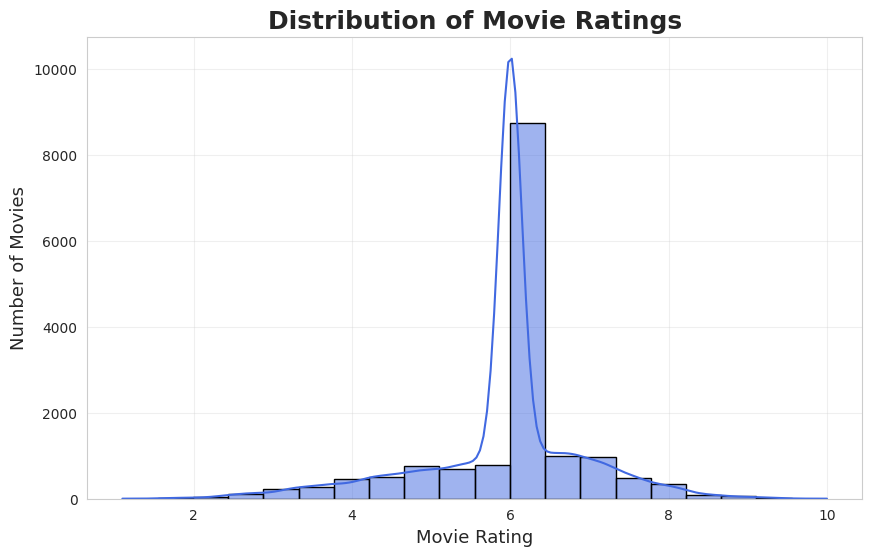

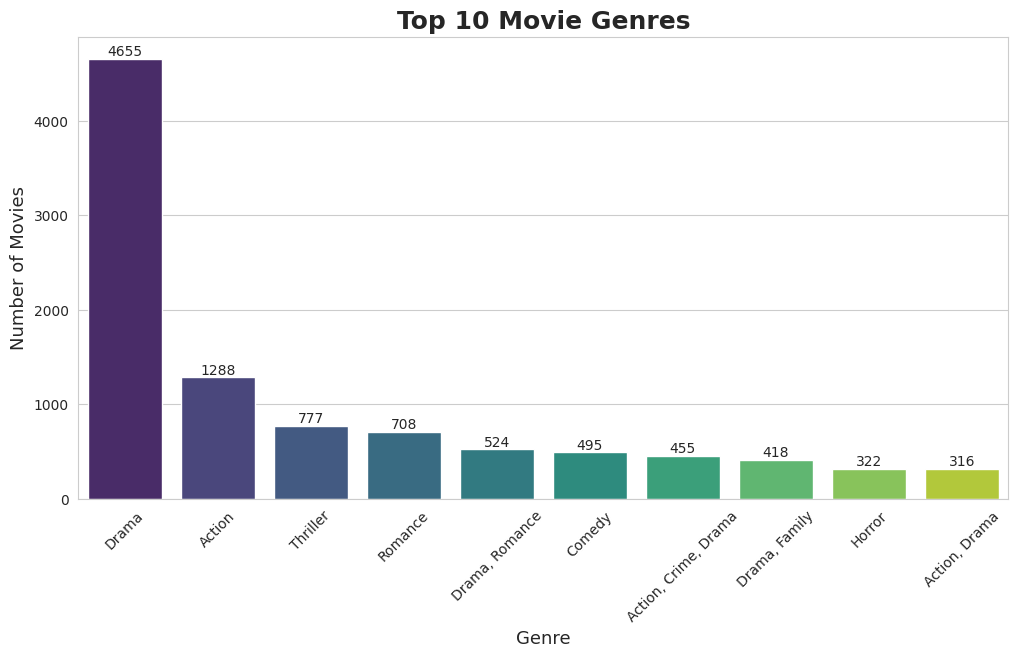

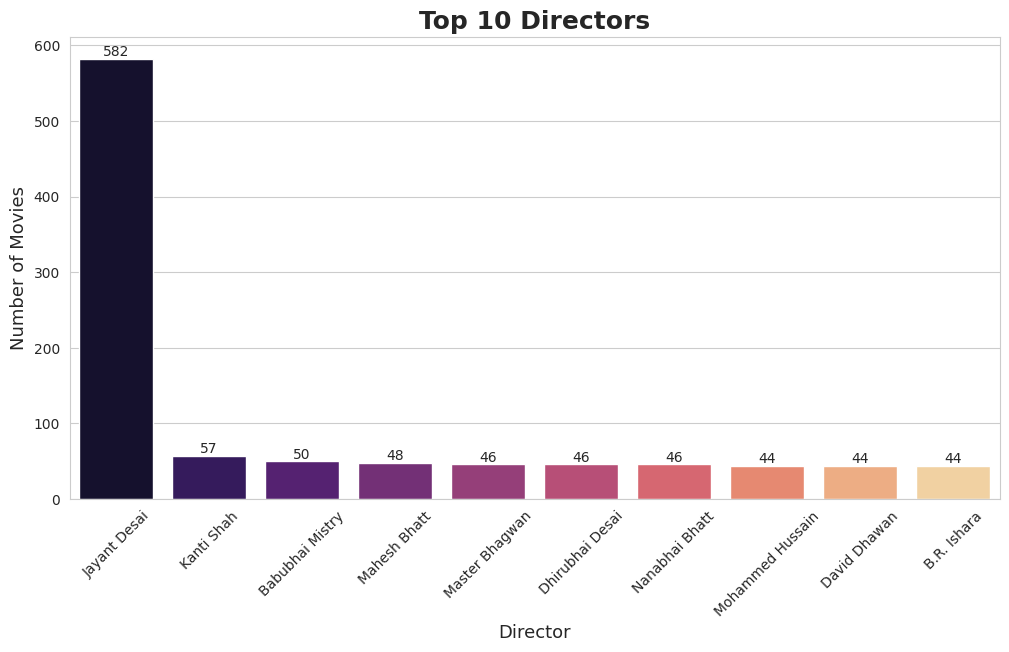

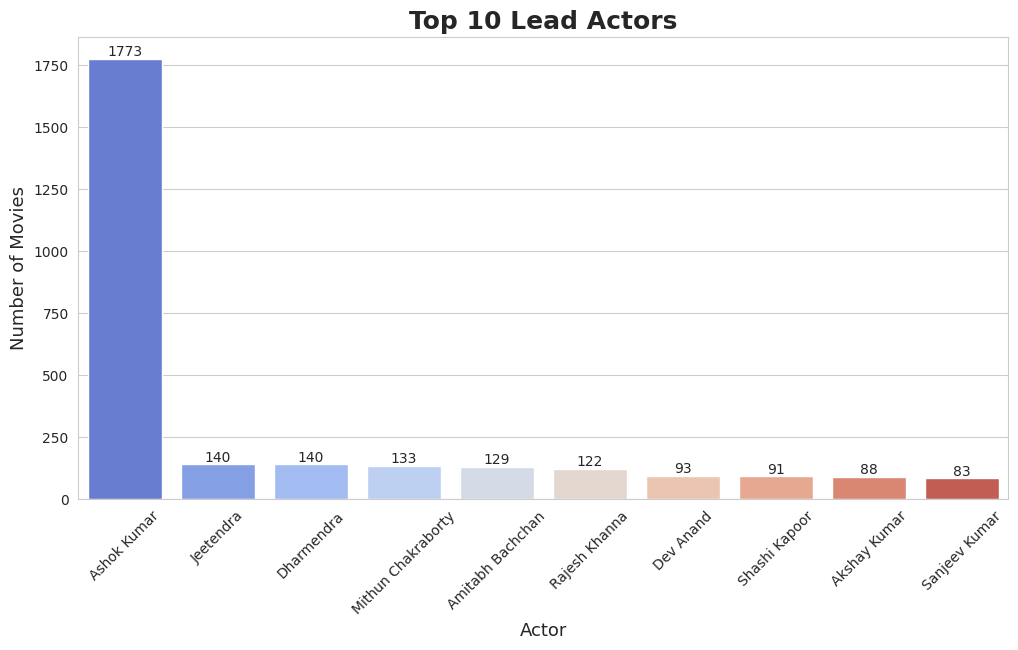

In [58]:
# ==========================================
# STEP 4 : Beautiful Data Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Graph Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# --------------------------------------------------
# 1. Rating Distribution
# --------------------------------------------------

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Rating",
    bins=20,
    kde=True,
    color="royalblue",
    edgecolor="black"
)

plt.title("Distribution of Movie Ratings", fontsize=18, fontweight="bold")
plt.xlabel("Movie Rating", fontsize=13)
plt.ylabel("Number of Movies", fontsize=13)

plt.grid(alpha=0.3)
plt.show()


# --------------------------------------------------
# 2. Top 10 Genres
# --------------------------------------------------

top_genres = df["Genre"].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_genres.index,
    y=top_genres.values,
    palette="viridis"
)

plt.title("Top 10 Movie Genres", fontsize=18, fontweight="bold")
plt.xlabel("Genre", fontsize=13)
plt.ylabel("Number of Movies", fontsize=13)

plt.xticks(rotation=45)

# Show values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()


# --------------------------------------------------
# 3. Top 10 Directors
# --------------------------------------------------

top_directors = df["Director"].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_directors.index,
    y=top_directors.values,
    palette="magma"
)

plt.title("Top 10 Directors", fontsize=18, fontweight="bold")
plt.xlabel("Director", fontsize=13)
plt.ylabel("Number of Movies", fontsize=13)

plt.xticks(rotation=45)

# Show values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()


# --------------------------------------------------
# 4. Top 10 Actors
# --------------------------------------------------

top_actors = df["Actor 1"].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_actors.index,
    y=top_actors.values,
    palette="coolwarm"
)

plt.title("Top 10 Lead Actors", fontsize=18, fontweight="bold")
plt.xlabel("Actor", fontsize=13)
plt.ylabel("Number of Movies", fontsize=13)

plt.xticks(rotation=45)

# Show values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [59]:
# ==========================================
# STEP 5 : Feature Engineering
# ==========================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Features
X = df[["Year","Duration","Votes","Genre","Director","Actor 1","Actor 2","Actor 3"]]

# Target
y = df["Rating"]

print("✅ Feature Engineering Completed")
X.head()

✅ Feature Engineering Completed


,Year,Duration,Votes,Genre,Director,Actor 1,Actor 2,Actor 3
0,1991.0,131.0,55.0,299,1926,2250,800,3108
1,2019.0,109.0,8.0,299,1548,3280,4790,527
2,2021.0,90.0,55.0,351,5123,3713,2866,3450
3,2019.0,110.0,35.0,228,3319,2917,1504,4020
4,2010.0,105.0,55.0,299,385,3112,3462,405


In [60]:
# ==========================================
# STEP 6 : Train Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (12402, 8)
Testing Data : (3101, 8)


In [61]:
# ==========================================
# STEP 7 : Model Training
# ==========================================

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model Trained Successfully")

✅ Model Trained Successfully


In [62]:
# ==========================================
# STEP 8 : Prediction
# ==========================================

prediction = model.predict(X_test)

prediction[:10]

array([7.118 , 5.248 , 6.949 , 6.    , 6.    , 5.892 , 6.786 , 6.001 ,
       6.5915, 4.96  ])

In [63]:
# ==========================================
# STEP 9 : Model Evaluation
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("R² Score :", round(r2_score(y_test, prediction),3))
print("MAE :", round(mean_absolute_error(y_test, prediction),3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, prediction)),3))

R² Score : 0.339
MAE : 0.444
RMSE : 0.804


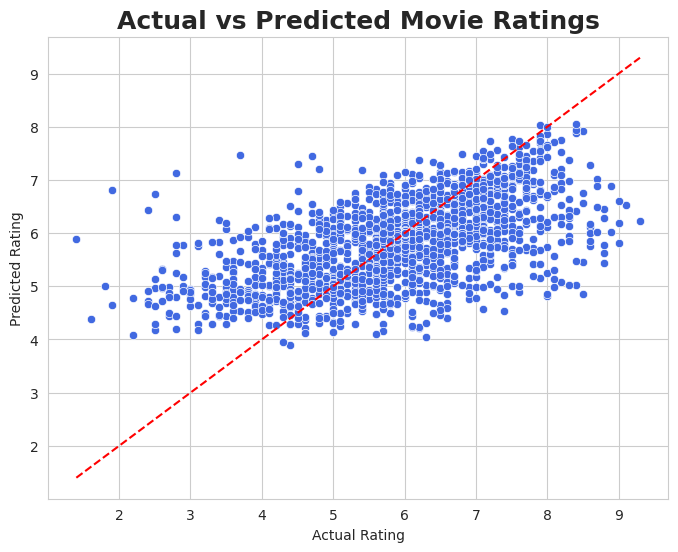

In [64]:
# ==========================================
# STEP 10 : Actual vs Predicted
# ==========================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=prediction,
    color="royalblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted Movie Ratings", fontsize=18, fontweight="bold")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.grid(True)

plt.show()

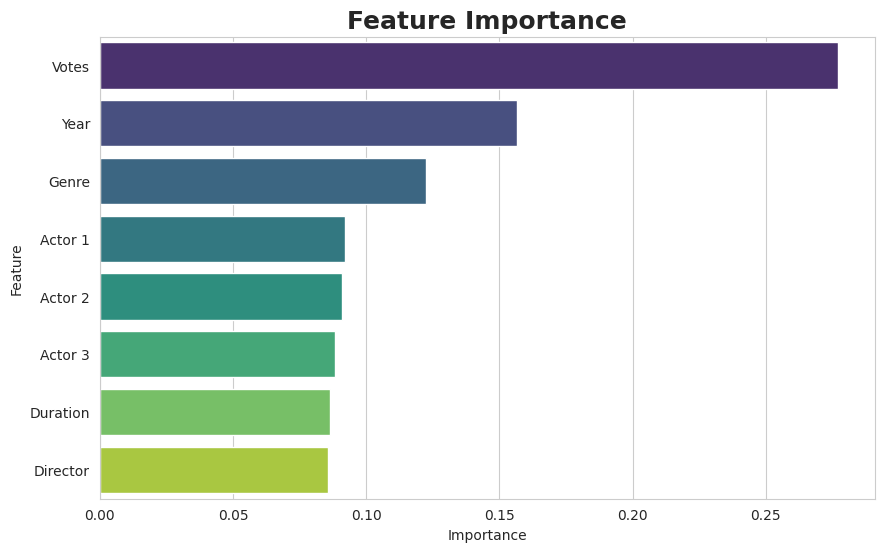

In [65]:
# ==========================================
# STEP 11 : Feature Importance
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance", fontsize=18, fontweight="bold")

plt.show()

# Conclusion

- Successfully loaded and cleaned the movie dataset.
- Performed Exploratory Data Analysis (EDA).
- Encoded categorical features.
- Trained a Random Forest Regressor model.
- Predicted movie ratings successfully.
- Evaluated the model using R² Score, MAE, and RMSE.
- The model can estimate movie ratings based on movie attributes such as Genre, Director, Actors, Duration, Votes, and Year.